# Generate callibration data

The goal of the callibration data is to pre-train the network by mapping parts of the sinogram to corresponding pixels. 

The data will consist of a few squares of bone and water on an empty background. The network will be trained on input/output with a single step so no reconstruction algorithm is needed for this data. 

The network will be trained with only a single step, as the data should be easy to interpret with very little information per image. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from libs.simulatepreps import projectMatrix


## Generate matrices

The matrices will consist of squares of bone and water scattered across the image. This is done to pre-train the network by mapping pixels onto the sinogram.

In [3]:
# Generate 32 x 32 x 32 phantom with random squares of water and bone.
# The sizes of the squares can vary between min_size and max_size.
# The value of the bone and water can vary between 0.5 and 1.0.

def generate_phantom(min_size, max_size, number_of_squares):

    water = np.zeros((32, 32, 32))
    bone = np.zeros((32, 32, 32))

    # fill water
    for i in range(number_of_squares):
        
        # Random size for each square
        water_sizes = np.random.randint(min_size, max_size, size=3)
        water_x, water_y, water_z = np.random.randint(0, 32 - np.array(water_sizes), size=3)

        water[water_x:water_x + water_sizes[0], water_y:water_y + water_sizes[1], water_z:water_z + water_sizes[2]] = np.random.uniform(0.5,1.0)
        
        bone_sizes = np.random.randint(min_size, max_size, size=3)
        bone_x, bone_y, bone_z = np.random.randint(0, 32 - np.array(bone_sizes), size=3)
        bone[bone_x:bone_x + bone_sizes[0], bone_y:bone_y + bone_sizes[1], bone_z:bone_z + bone_sizes[2]] = np.random.uniform(0.5, 1)

    return  bone, water



In [4]:
# Settings 

projections = 32                        # Number of projections
nSubset = 1                             # Number of subsets (based on meeting: change to 1 if algorithm messes up)
objectSize = 32                         # Object Size a square
nIter = 20                              # Number of iterations for mechlem algorithm
nPixelsY = 64                           # Number of pixels on the detector plate.
nPixelsZ = 44                           # Number of pixels on the detector plate.
pixelPitch = 1                          # Pixel pitch (not sure; ask!)
nPixelsPerProj = nPixelsZ * nPixelsY    # The total number of pixels on the detector plate

In [5]:
bone, water = generate_phantom(2, 5, 5)
x = np.column_stack((bone.ravel(), water.ravel()))  # x is the input matrix
y, _, _, _ = projectMatrix(x, objectSize, nPixelsY, nPixelsZ, pixelPitch, projections)

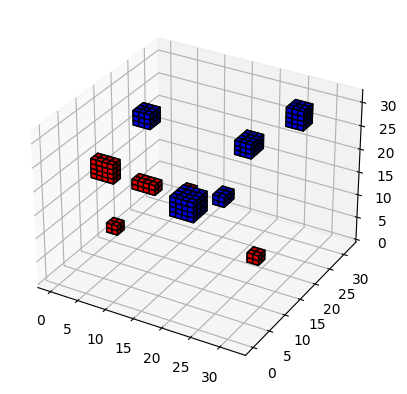

In [ ]:
#| label: callibration-3d

import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create a 3D boolean mask for each material
water_mask = water != 0
bone_mask = bone != 0

# Combine masks into one grid
voxels = water_mask | bone_mask

# Assign colors: use a dict with (z, y, x): color
colors = np.empty(voxels.shape, dtype=object)
colors[water_mask] = 'blue'
colors[bone_mask] = 'red'

ax.voxels(voxels, facecolors=colors, edgecolor='k')

# add legend
ax.text2D(0.05, 0.95, "Water", transform=ax.transAxes, color='blue')
ax.text2D(0.05, 0.90, "Bone", transform=ax.transAxes, color='red')

plt.show()